<a href="https://colab.research.google.com/github/pavanthisppm/STAT852-Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
# ---------------------------------------------------------
# Dataset
# ---------------------------------------------------------
df = pd.read_csv('heart.csv')

X = df.drop('target', axis = 1)
y = df['target']

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.shape

(303, 14)

In [ ]:
# ---------------------------------------------------------
# Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# ---------------------------------------------------------
# Standardization
# ---------------------------------------------------------
sc = StandardScaler()

var_transform = ['thalach', 'age', 'trestbps', 'oldpeak', 'chol']
X_train[var_transform] = sc.fit_transform(X_train[var_transform])
X_test[var_transform] = sc.transform(X_test[var_transform])

X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,-1.356798,1,1,-0.616856,0.914034,0,1,0.532781,0,-0.920864,2,0,2
202,0.385086,1,0,1.169491,0.439527,0,0,-1.753582,1,-0.193787,2,0,3
196,-0.921327,1,2,1.169491,-0.300704,0,1,-0.139679,0,2.350982,1,0,2
75,0.058483,0,1,0.276318,0.059921,0,0,0.487950,0,0.351521,1,0,2
176,0.602822,1,0,-0.795490,-0.319684,1,1,0.443119,1,0.351521,2,2,3


In [ ]:
# ---------------------------------------------------------
# Hyperparameter tuning for base models
# ---------------------------------------------------------

# --- KNN ---
knn_params = {
    'n_neighbors': [5, 6, 9, 11],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
print("Best KNN:", knn_grid.best_params_)

# --- Logistic Regression ---
lr_params = {'C': [10, 50], 'penalty': ['l2'], 'solver': ['lbfgs'], 'max_iter': [1000]}
lr_grid = GridSearchCV(LogisticRegression(), lr_params, cv=5)
lr_grid.fit(X_train, y_train)
best_lr_base = lr_grid.best_estimator_
print("Best Logistic Regression (Base):", lr_grid.best_params_)

# --- Naive Bayes ---
nb_params = {'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8]}
nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5)
nb_grid.fit(X_train, y_train)
best_nb = nb_grid.best_estimator_
print("Best Naive Bayes:", nb_grid.best_params_)

# ---------------------------------------------------------
# Meta-model: XGBoost
# ---------------------------------------------------------
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42),
    xgb_params, cv=5
)
xgb_grid.fit(X_train, y_train)
meta_xgb = xgb_grid.best_estimator_
print("Best XGBoost Meta-model:", xgb_grid.best_params_)

# ---------------------------------------------------------
# Evaluate individual base models
# ---------------------------------------------------------
base_models = {
    'KNN': best_knn,
    'LogisticRegression': best_lr_base,
    'NaiveBayes': best_nb,
    'XGBoost': meta_xgb
}

for name, model in base_models.items():
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    avg_method = "binary" if len(np.unique(y_train)) == 2 else "weighted"

    train_f1  = f1_score(y_train, train_pred, average=avg_method)
    test_f1   = f1_score(y_test, test_pred, average=avg_method)

    print(f"\n{name} Results:")
    print(f"Train F1: {train_f1:.4f}")
    print(f"Test  F1: {test_f1:.4f}")

# ---------------------------------------------------------
# Build stacking model
# ---------------------------------------------------------
stacking_model = StackingClassifier(
    estimators=[
        ('knn', best_knn),
        ('lr', best_lr_base),
        ('nb', best_nb)
    ],
    final_estimator=meta_xgb,
    cv=5,
    passthrough=True
)

stacking_model.fit(X_train, y_train)

stack_train_pred = stacking_model.predict(X_train)
stack_test_pred  = stacking_model.predict(X_test)

stack_train_f1  = f1_score(y_train, stack_train_pred, average=avg_method)
stack_test_f1   = f1_score(y_test, stack_test_pred, average=avg_method)

print("\nSTACKING Results:")
print(f"Train F1: {stack_train_f1:.4f}")
print(f"Test  F1: {stack_test_f1:.4f}")



Best KNN: {'n_neighbors': 6, 'weights': 'uniform'}
Best Logistic Regression (Base): {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Naive Bayes: {'var_smoothing': 1e-12}
Best XGBoost Meta-model: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}

KNN Results:
Train F1: 0.8797
Test  F1: 0.8710

LogisticRegression Results:
Train F1: 0.8809
Test  F1: 0.8571

NaiveBayes Results:
Train F1: 0.8382
Test  F1: 0.8710

XGBoost Results:
Train F1: 0.8849
Test  F1: 0.8788

STACKING Results:
Train F1: 0.9037
Test  F1: 0.8923


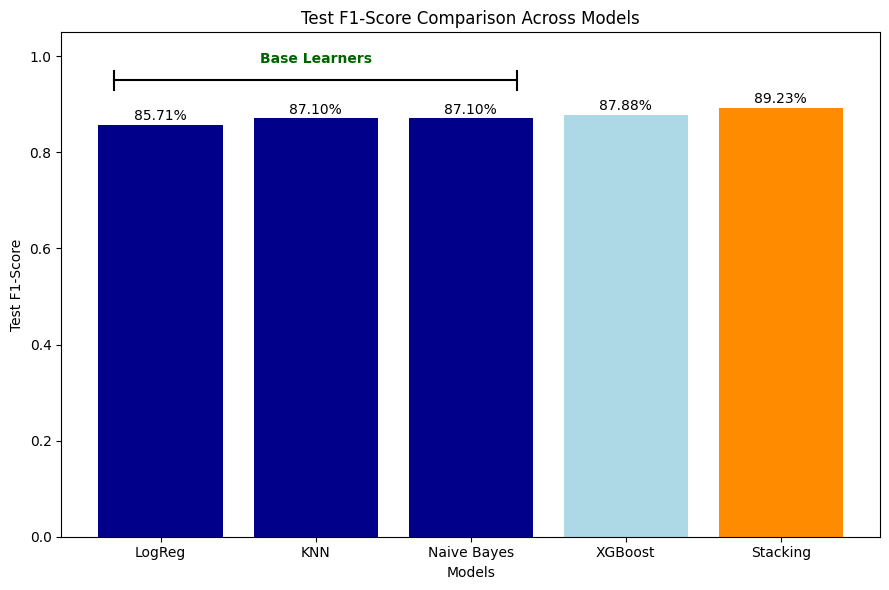

In [ ]:
# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

models = ['LogReg', 'KNN', 'Naive Bayes', 'XGBoost', 'Stacking']

f1_score = [
    0.8571,     # Logistic Regression
    0.8710,     # KNN
    0.8710,     # Naive Bayes
    0.8788,     # XGBoost
    0.8923      # Stacking
]


colors = ['darkblue', 'darkblue', 'darkblue', 'lightblue', 'darkorange']


plt.figure(figsize=(9, 6))
plt.bar(models, f1_score, color=colors)
plt.xlabel('Models')
plt.ylabel('Test F1-Score')
plt.title('Test F1-Score Comparison Across Models')


plt.ylim(0, 1.05)


for i, v in enumerate(f1_score):
    plt.text(i, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=10)

# ---------------------------------
# Add Bracket and Label for Base Learners
# ---------------------------------
y_bracket = 0.95
y_cap_low = 0.93
y_cap_high = 0.97
x_start = -0.3
x_end = 2.3

# Horizontal line
plt.plot([x_start, x_end], [y_bracket, y_bracket], color='black', linewidth=1.5)
# Left cap (vertical line)
plt.plot([x_start, x_start], [y_cap_low, y_cap_high], color='black', linewidth=1.5)
# Right cap (vertical line)
plt.plot([x_end, x_end], [y_cap_low, y_cap_high], color='black', linewidth=1.5)

# Label for Base Learners
plt.text(1.0, 0.98, 'Base Learners', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkgreen')

plt.tight_layout()

plt.savefig('model_f1score_with_base_learners.png')